# Conservation Law

A scalar conservation law has the form:

$$\frac{\partial u}{\partial t} + \frac{\partial F(u)}{\partial x} = 0$$

The wave speed $a(u) = dF/du$ determines how fast information propagates and in which direction. When $a$ changes sign the problem is genuinely nonlinear and shocks or rarefactions can form.

We demonstrate the **LWR traffic flow model** where $\rho$ is vehicle density and $F(\rho) = \rho(1-\rho)$ is the flow rate. The wave speed $a = 1 - 2\rho$ is positive for low density and negative for high density — vehicles slow down in traffic.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# run pip install -e . to install package
from upde import PDE, PDESystem, ConservationLaw

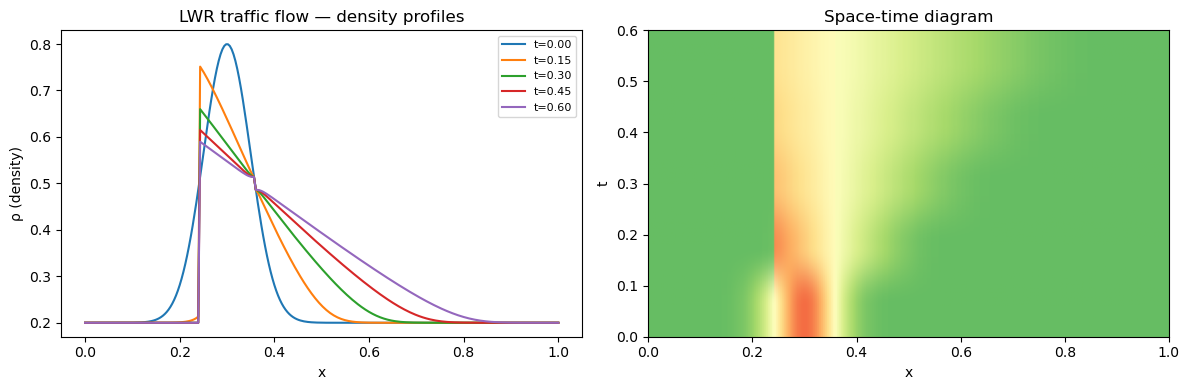

In [2]:
x = np.linspace(0, 1, 256)

# Traffic flow: F(rho) = rho*(1 - rho)
# Wave speed a = dF/drho = 1 - 2*rho  (changes sign at rho=0.5)
eq = ConservationLaw('rho', x=x, flux=lambda rho: rho * (1 - rho))
eq.set_bc(kind='periodic')

# IC: smooth density variation — high density hump on the left
rho0 = 0.2 + 0.6 * np.exp(-((x - 0.3)**2) / 0.005)
rho0 = np.clip(rho0, 0, 1)
eq.set_ic(rho0)

sol = eq.solve(t_span=(0, 0.6), method='RK45',
                            t_eval=np.linspace(0, 0.6, 5),
                            rtol=1e-4, atol=1e-6)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Profiles
for k, t in enumerate(sol.t):
    axes[0].plot(x, sol.rho[:, k], label=f't={t:.2f}')
axes[0].set_xlabel('x'); axes[0].set_ylabel('ρ (density)')
axes[0].set_title('LWR traffic flow — density profiles')
axes[0].legend(fontsize=8)

# Space-time diagram
axes[1].imshow(sol.rho.T, origin='lower', aspect='auto',
               extent=[0,1,0,0.6], cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_xlabel('x'); axes[1].set_ylabel('t')
axes[1].set_title('Space-time diagram')

plt.tight_layout(); plt.show()